In [1]:
from datetime import datetime
from siphon.simplewebservice.igra2 import IGRAUpperAir

In [2]:
date = datetime(2014, 9, 10, 0)
station = 'USM00070026'
df, header = IGRAUpperAir.request_data(date, station)
print(df.columns)

# Inspect metadata from the data headers
print(header.columns)

Index(['lvltyp1', 'lvltyp2', 'etime', 'pressure', 'pflag', 'height', 'zflag',
       'temperature', 'tflag', 'relative_humidity', 'direction', 'speed',
       'date', 'u_wind', 'v_wind', 'dewpoint'],
      dtype='object')
Index(['site_id', 'year', 'month', 'day', 'hour', 'release_time',
       'number_levels', 'pressure_source_code', 'non_pressure_source_code',
       'latitude', 'longitude', 'date'],
      dtype='object')


<Axes: xlabel='temperature', ylabel='pressure'>

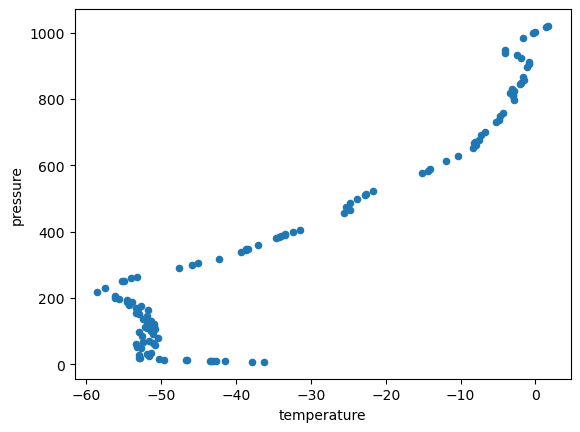

In [3]:
df.plot(y='pressure', x='temperature', kind='scatter')

--- Starting Search for Closest Sounding ---
Target: 2025-05-15 12:00 UTC at (67.85579, 20.2252)


/projekt_agmwend/home_rad/Joshua/tmp/ipykernel_3564738/298158425.py:50: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  current_year = datetime.utcnow().year



Found 5 potential stations. Checking for data...

Attempting Station: ANDOYA (NOM00001010) | Distance: 231.61 km
  -> Checking for sounding at 2025-05-15 12:00 UTC...
✅ Success! Found data for ANDOYA at 2025-05-15 12:00 UTC.

--- Sounding Data Retrieved ---

Header Information:
       site_id  year  month  day  hour  release_time  number_levels  \
0  NOM00001010  2025      5   15    12          4200             89   

  pressure_source_code  non_pressure_source_code  latitude  longitude  \
0             ncdc-gts                       NaN   69.3073    16.1312   

                 date  
0 2025-05-15 12:00:00  

Sounding Data (first 10 levels):
   lvltyp1  lvltyp2  etime  pressure  pflag  height  zflag  temperature  \
0        2        1      0   1019.87      2       3      0          7.0   
1        2        0     13   1012.04      1      66      2          5.5   
2        1        0     32   1000.00      0     164      2          4.3   
3        2        0     39    995.64      0     

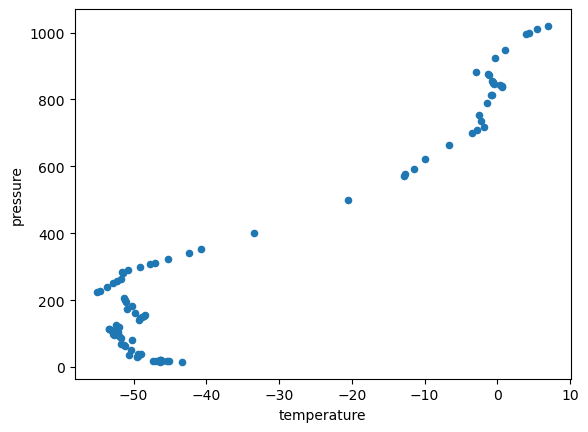

In [4]:
import pandas as pd
import numpy as np
import requests
from datetime import datetime, timedelta
from siphon.simplewebservice.igra2 import IGRAUpperAir

def get_station_list(url="https://www.ncei.noaa.gov/pub/data/igra/igra2-station-list.txt"):
    """
    Downloads and parses the IGRAv2 station list into a pandas DataFrame.
    
    Args:
        url (str): The URL to the IGRA station list.
        
    Returns:
        pandas.DataFrame: A DataFrame containing the list of all IGRA stations.
    """
    try:
        # Corrected column specifications based on the IGRAv2 documentation
        col_specs = [
            (0, 11), (12, 20), (21, 30), (31, 37), (38, 40), 
            (41, 71), (72, 76), (77, 81), (82, 88)
        ]
        names = [
            'id', 'latitude', 'longitude', 'elevation', 'state', 
            'name', 'first_year', 'last_year', 'num_obs'
        ]
        
        # Read the station list into a pandas DataFrame
        station_df = pd.read_fwf(url, colspecs=col_specs, names=names)
        return station_df
    except Exception as e:
        print(f"Error downloading or parsing station list: {e}")
        return None

def find_closest_active_stations(stations_df, lat, lon, n=5):
    """
    Finds the N closest *active* radiosonde stations from the station list.
    'Active' is defined as having reported data within the last 2 years.
    
    Args:
        stations_df (pandas.DataFrame): DataFrame of IGRA stations.
        lat (float): Target latitude.
        lon (float): Target longitude.
        n (int): The number of closest stations to return.
        
    Returns:
        pandas.DataFrame: A DataFrame of the N closest active stations, sorted by distance.
    """
    # Filter for stations that are likely active
    current_year = datetime.utcnow().year
    active_stations = stations_df[stations_df['last_year'] >= current_year - 1].copy()
    
    # Calculate distance using the Haversine formula for accuracy
    lat_rad = np.radians(lat)
    lon_rad = np.radians(lon)
    stations_lat_rad = np.radians(active_stations['latitude'])
    stations_lon_rad = np.radians(active_stations['longitude'])

    dlon = stations_lon_rad - lon_rad
    dlat = stations_lat_rad - lat_rad
    a = np.sin(dlat / 2)**2 + np.cos(lat_rad) * np.cos(stations_lat_rad) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    distance = 6371 * c  # Radius of Earth in kilometers

    active_stations['distance_km'] = distance
    
    return active_stations.sort_values(by='distance_km').head(n)

def get_closest_sounding(target_dt, lat, lon):
    """
    Finds and retrieves the closest available radiosonde sounding data.
    
    This function finds the nearest active radiosonde station, then attempts
    to download data for the specified time. If that fails, it checks the
    standard 00Z and 12Z launch times for that day.
    
    Args:
        target_dt (datetime): The desired date and time for the sounding.
        lat (float): The target latitude.
        lon (float): The target longitude.
        
    Returns:
        tuple: A tuple containing:
            - pandas.DataFrame: The sounding data.
            - pandas.DataFrame: The header/metadata for the sounding.
        Returns (None, None) if no data can be found.
    """
    print("--- Starting Search for Closest Sounding ---")
    print(f"Target: {target_dt.strftime('%Y-%m-%d %H:%M')} UTC at ({lat}, {lon})")

    # 1. Get the full station list
    all_stations = get_station_list()
    if all_stations is None:
        return None, None
        
    # 2. Find the 5 closest active stations
    closest_stations = find_closest_active_stations(all_stations, lat, lon, n=5)
    if closest_stations.empty:
        print("No active stations found nearby.")
        return None, None
    
    print(f"\nFound {len(closest_stations)} potential stations. Checking for data...")

    # 3. Define potential times to check (target time, then 12Z and 00Z)
    base_date = datetime(target_dt.year, target_dt.month, target_dt.day)
    potential_times = [
        target_dt,
        base_date + timedelta(hours=12),
        base_date,
        base_date - timedelta(hours=12), 
        base_date - timedelta(hours=24)  # Also check the previous day
    ]
    # Remove duplicates if target time is already 00 or 12Z
    potential_times = sorted(list(set(potential_times)), key=lambda x: abs((x - target_dt).total_seconds()))

    # 4. Iterate through stations and times until data is found
    for index, station in closest_stations.iterrows():
        station_id = station['id']
        station_name = station['name'].strip()
        print(f"\nAttempting Station: {station_name} ({station_id}) | Distance: {station['distance_km']:.2f} km")
        
        for time_to_check in potential_times:
            print(f"  -> Checking for sounding at {time_to_check.strftime('%Y-%m-%d %H:%M')} UTC...")
            try:
                df, header = IGRAUpperAir.request_data(time_to_check, station_id)
                
                # Check if data was actually returned
                if df is not None and not df.empty:
                    print(f"✅ Success! Found data for {station_name} at {time_to_check.strftime('%Y-%m-%d %H:%M')} UTC.")
                    return df, header
                else:
                    # This case is handled by the exception Siphon throws, but is good practice.
                    pass
            except Exception as e:
                # Siphon often raises errors for 404s (no data), so we catch them gracefully
                # and just print a small note.
                # print(f"     Note: No data for this time/station ({e})")
                continue # Try the next time
                
    print("\n--- Search Complete: No data found for any nearby stations. ---")
    return None, None


if __name__ == '__main__':
    # --- Example Usage ---
    # Target location: Leipzig, Germany
    target_latitude = 67.85579
    target_longitude = 20.2252
    # Target time: Noon on a specific day
    target_datetime = datetime(2025, 5, 15, 12)

    # Get the sounding data
    sounding_df, header_df = get_closest_sounding(target_datetime, target_latitude, target_longitude)

    if sounding_df is not None:
        print("\n--- Sounding Data Retrieved ---")
        print("\nHeader Information:")
        print(header_df)
        
        print("\nSounding Data (first 10 levels):")
        print(sounding_df.head(10))
        sounding_df.plot(y='pressure', x='temperature', kind='scatter')
        
        # You can now use 'sounding_df' and 'header_df' for your analysis in Py-ART
        # For example, accessing specific columns:
        # pressure = sounding_df['pressure'].values
        # temperature = sounding_df['temperature'].values
        # dewpoint = sounding_df['dewpoint'].values
        # u_wind, v_wind = sounding_df['u_wind'].values, sounding_df['v_wind'].values


In [9]:
sounding_df

,lvltyp1,lvltyp2,etime,pressure,pflag,height,zflag,temperature,tflag,relative_humidity,direction,speed,date,u_wind,v_wind,dewpoint
0,2,1,0,1019.87,2,3,0,7.0,2,NaN,252,5.1,2025-05-15 12:00:00,4.9,1.6,4.1
1,2,0,13,1012.04,1,66,2,5.5,2,NaN,267,5.1,2025-05-15 12:00:00,5.1,0.3,3.1
2,1,0,32,1000.00,0,164,2,4.3,2,NaN,264,6.1,2025-05-15 12:00:00,6.1,0.6,2.1
3,2,0,39,995.64,0,199,2,4.0,2,NaN,262,6.3,2025-05-15 12:00:00,6.2,0.9,2.4
4,2,0,112,948.51,0,592,2,1.0,2,NaN,256,7.1,2025-05-15 12:00:00,6.9,1.7,-0.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,2,0,5568,17.45,0,27707,2,-46.5,1,NaN,135,7.9,2025-05-15 12:00:00,-5.6,5.6,-82.3
85,2,0,5615,16.71,0,27992,2,-47.0,1,NaN,174,5.1,2025-05-15 12:00:00,-0.5,5.1,-82.4
86,2,0,5630,16.50,0,28076,2,-47.3,1,NaN,196,3.6,2025-05-15 12:00:00,1.0,3.5,-82.7
87,2,0,5650,16.22,0,28189,2,-46.4,1,NaN,155,0.1,2025-05-15 12:00:00,-0.0,0.1,-82.7
